<a href="https://colab.research.google.com/github/tayaland1514/statprak_hw/blob/main/hw7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
all_data = pd.read_csv('datasets/forest_dataset.csv')
all_data.head()

,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
0,2683,333,35,30,26,2743,121,173,179,6572,...,0,0,0,0,0,0,0,0,0,2
1,2915,90,8,216,11,4433,232,228,129,4019,...,0,0,0,0,0,0,0,0,0,1
2,2941,162,7,698,76,2783,227,242,148,1784,...,0,0,0,0,0,0,0,0,0,2
3,3096,60,17,170,3,3303,231,202,99,5370,...,0,0,0,0,0,0,0,0,0,1
4,2999,66,8,488,37,1532,228,225,131,2290,...,0,0,0,0,0,0,0,0,0,2


In [ ]:
labels = all_data[all_data.columns[-1]].values
feature_matrix = all_data[all_data.columns[:-1]].values

In [ ]:
from sklearn.model_selection import train_test_split
train_feature_matrix, test_feature_matrix, train_labels, test_labels = train_test_split(feature_matrix, labels, test_size=0.2, random_state=42)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

clf = KNeighborsClassifier()
clf.fit(train_feature_matrix, train_labels)
y_pred = clf.predict(test_feature_matrix)
accuracy_score(test_labels, y_pred)

0.7365

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_neighbors': np.arange(1, 11),
    'metric': ['manhattan', 'euclidean'],
    'weights': ['uniform', 'distance']
}
clf = KNeighborsClassifier()
clf_grid = GridSearchCV(clf, params, cv=5, scoring='accuracy', n_jobs=-1)
clf_grid.fit(train_feature_matrix, train_labels)
clf_grid.best_params_

{'metric': 'manhattan', 'n_neighbors': np.int64(4), 'weights': 'distance'}

In [ ]:
optimal_clf = KNeighborsClassifier(
    n_neighbors=clf_grid.best_params_['n_neighbors'],
    metric=clf_grid.best_params_['metric'],
    weights=clf_grid.best_params_['weights']
)
optimal_clf.fit(train_feature_matrix, train_labels)
knn_pred = optimal_clf.predict(test_feature_matrix)
knn_accuracy = accuracy_score(test_labels, knn_pred)
knn_accuracy

0.7845

In [ ]:
pred_prob = optimal_clf.predict_proba(test_feature_matrix)

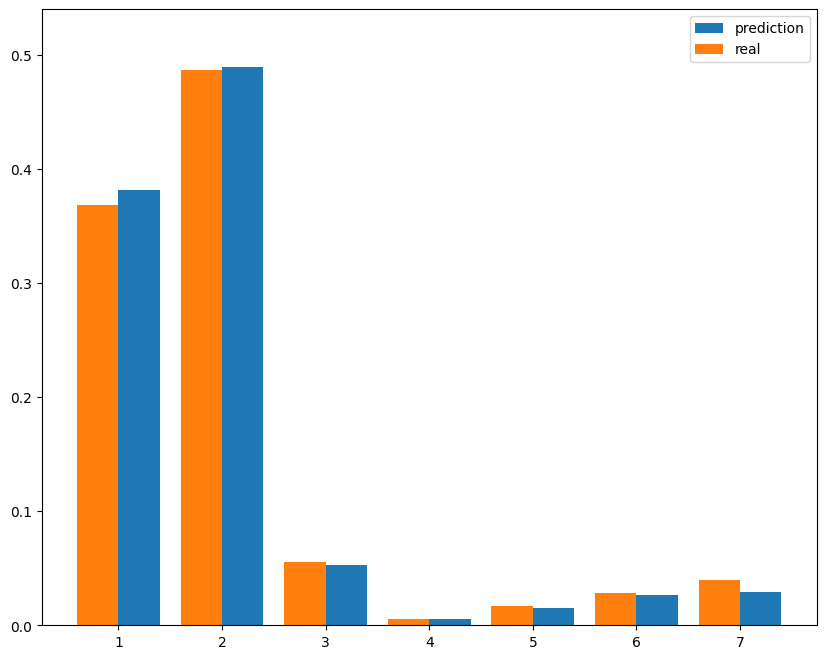

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

unique, freq = np.unique(test_labels, return_counts=True)
freq = list(map(lambda x: x / len(test_labels), freq))
pred_freq = pred_prob.mean(axis=0)

plt.figure(figsize=(10, 8))
plt.bar(range(1, 8), pred_freq, width=0.4, align="edge", label='prediction')
plt.bar(range(1, 8), freq, width=-0.4, align="edge", label='real')
plt.ylim(0, 0.54)
plt.legend()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(C=1, max_iter=5000)
log_reg.fit(train_feature_matrix, train_labels)
log_reg_pred = log_reg.predict(test_feature_matrix)
log_reg_accuracy = accuracy_score(test_labels, log_reg_pred)
print("KNN:", knn_accuracy)
print("LogReg:", log_reg_accuracy)

KNN: 0.7845
LogReg: 0.701


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Каково качество модели на тестовой выборке? Сравните его с качеством логистической регрессии. Какая модель лучше? Почему?

0.7845 > 0.701 => модель knn показывает более высокую точность, чем логистическая регрессия, тк модель knn правильно классифицирует примерно 78.45% объектов тестовой выборки, а модель логистической регрессии дает примерно 70.1% правильных ответов, что меньше

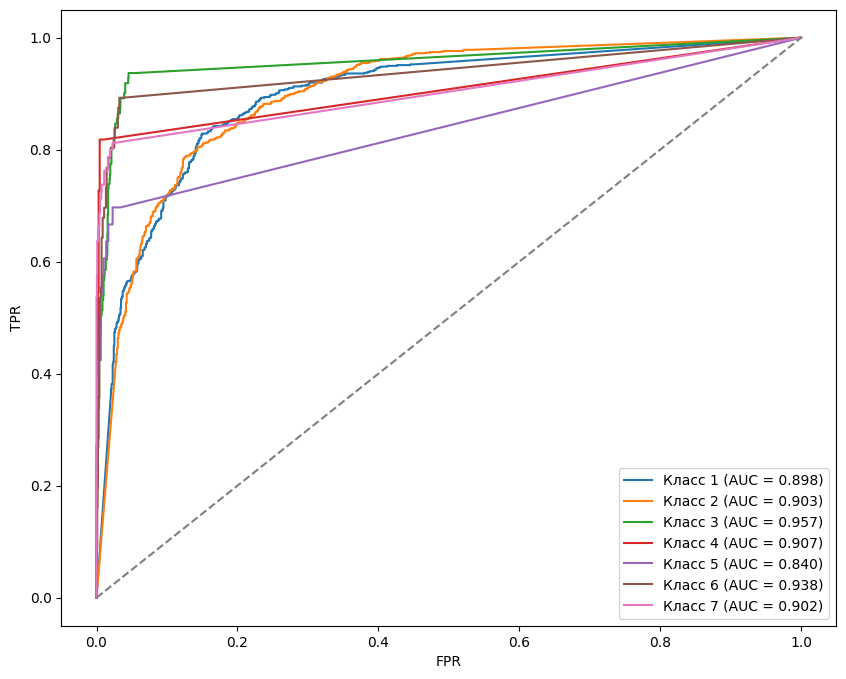

Площадь под ROC-кривой: 0.9063452430548241


In [26]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

classes = np.unique(labels)
test_labels_bin = label_binarize(test_labels, classes=classes)
n_classes = test_labels_bin.shape[1]
fpr = {}
tpr = {}
roc_auc = {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Класс {classes[i]} (AUC = {roc_auc[i]:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

print("Площадь под ROC-кривой:", roc_auc_score(test_labels_bin, pred_prob, multi_class='ovr', average='macro'))

Каковы преимущества и недостатки метода k ближайших соседей?

преимущества:
- простой идейно и в реализации
- обучение сводится к запоминанию обучающей выборки, поэтому происходит быстро

недостатки:
- необходимость хранения все обучающей выборки
- сильная зависимость от шума и выбросов
- чувствительность к гиперпараметрам и масштабу признаков